# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
import os
import shutil
import warnings
from functools import partial
from pprint import pprint
from typing import Callable

from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

tqdm.pandas()
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import DatasetDict
from semhash import SemHash
from sentence_transformers import SentenceTransformer, util
from torch import Tensor

sns.set(style="whitegrid")

np.random.seed(0)

In [4]:
from experiments.audio import calculate_audio_duration
from experiments.constants import INFINITY_INSTRUCT__CONFIG, TTS_CONFIGS, TTSConfig
from experiments.io import load_dataset as src_load_dataset
from experiments.io import save_json, save_parquet
from experiments.languages import LanguageClassifier, LanguageTranslator
from experiments.nlp import TTS, split_into_sentences

In [ ]:
from mllm_shap.connectors import LiquidAudio
from mllm_shap.connectors.enums import ModelHistoryTrackingMode, Role, SystemRolesSetup
from mllm_shap.connectors.filters import ExcludePunctuationTokensFilter

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
model_for_tokens = LiquidAudio(device=device, history_tracking_mode=ModelHistoryTrackingMode.TEXT)

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
def compute_multi_turn_token_counts(input_df, sentences_column="sentences") -> list:
    """Compute number of tokens (mask sum) for each text entry.

    For each row we create a fresh chat, keep the system instruction the same
    and set the user turn text to the dataset entry. Returns a list of ints.
    """
    token_counts = []
    for sentences in tqdm(input_df[sentences_column].tolist(), desc="multi-turn token counting"):
        chat_local = model_for_tokens.get_new_chat(
            system_roles_setup=SystemRolesSetup.SYSTEM_ASSISTANT,
            token_filter=ExcludePunctuationTokensFilter(),
        )
        chat_local.new_turn(Role.SYSTEM)
        chat_local.add_text("You are a helpful assistant.")
        chat_local.end_turn()

        for sentence in sentences:
            chat_local.new_turn(Role.USER)
            chat_local.add_text(sentence)
            chat_local.end_turn()

        # mask sum is the number of tokens considered for explainability
        tokens = int(chat_local.shap_values_mask.sum().item())
        token_counts.append(tokens)
    return token_counts

Embedding model is later used to search for labels in dataset that are similar to pre-defined terms. Model has been chosen based on official docs, claimed to be fast and to perform well on small terms - our search is one-word mostly.

In [ ]:
FRENCH_LANGUAGE_CODE: str = "fr"
ENGLISH_LANGUAGE_CODE: str = "en"
SPANISH_LANGUAGE_CODE: str = "es"

LANGUAGE_MINIMAL_POPULATION: int = 1000
MAXIMUM_NUMBER_OF_TURNS: int = 4
MAX_SENTENCE_LENGTH: int = 200

ABILITIES_TO_EXCLUDE: set[str] = {
    "formal logic",
    "logical reasoning",
    "mathematics",
    "programming",
}
LABELS_EXCLUSION_THRESHOLD: float = 0.4

MIN_NUMBER_OF_TURNS_TO_INCLUDE: int = 2
MAX_NUMBER_OF_TURNS_TO_INCLUDE: int = 4

tts: TTS = TTS()
language_classifier: LanguageClassifier = LanguageClassifier()
language_translator: LanguageTranslator = LanguageTranslator()

load_dataset: Callable[[str], DatasetDict] = partial(src_load_dataset, config=INFINITY_INSTRUCT__CONFIG)
embedding_model = SentenceTransformer("multi-qa-MiniLM-L6-cos-v1")


def get_sample_df(df_to_sample: pd.DataFrame, main_field_key: str = "sentences") -> pd.DataFrame:
    """
    For each dataset, get a sample with the longest text (in sentences).

    Args:
        df_to_sample: The DataFrame to sample from with 'labels' and 'sentences' columns.
        main_field_key: The main field to include in the output DataFrame.
    Returns:
        A DataFrame containing one sample per dataset with the longest text.
    """
    _group_by_terms = ["labels"]
    _select_terms = ["label", main_field_key, "sentences__num"]
    if "language" in df_to_sample.columns:  # pylint: disable=magic-value-comparison
        _group_by_terms.append("language")
        _select_terms.append("language")

    return (
        df_to_sample.explode("labels")
        .groupby(_group_by_terms, group_keys=False)
        .apply(lambda g: g.loc[g["sentences__num"].idxmin()], include_groups=False)
        .sort_index()
        .reset_index()
        .rename(columns={"labels": "label"})[_select_terms]
    )


# pylint: disable=duplicate-code
def get_df_stats(df_to_analyze: pd.DataFrame, include_audio_: bool = True) -> dict[str, float]:
    """
    Get statistics for the entire DataFrame.

    Args:
        df_to_analyze: The DataFrame to analyze with a 'conversation__joined' and 'sentences__num' columns.
        include_audio_: Whether to include audio duration statistics.
    """
    characters__num = df_to_analyze["conversation__joined"].apply(len)
    unique_entries = df_to_analyze["conversation__joined"].nunique()

    stats = {
        "rows__num": len(df_to_analyze),
        "characters__num": round(characters__num.sum().item(), 2),
        "avg_characters__num": round(characters__num.mean().item(), 2),
        "total_sentences__num": round(df_to_analyze["sentences__num"].sum().item(), 2),
        "avg_sentences__num": round(df_to_analyze["sentences__num"].mean().item(), 2),
        "min_sentences__num": df_to_analyze["sentences__num"].min().item(),
        "unique_entries__num": unique_entries,
        "unique_entries__pct": round(unique_entries / len(df_to_analyze) * 100, 2),
    }

    if include_audio_:
        if isinstance(df_to_analyze.reset_index(drop=True).loc[0, "audio__female__duration"][0], list):
            audio__female__duration__per_entry = df_to_analyze["audio__female__duration"].apply(
                lambda x: sum(sum(e) for e in x)
            )
            audio__male__duration__per_entry = df_to_analyze["audio__male__duration"].apply(
                lambda x: sum(sum(e) for e in x)
            )
        else:
            audio__female__duration__per_entry = df_to_analyze["audio__female__duration"].apply(sum)
            audio__male__duration__per_entry = df_to_analyze["audio__male__duration"].apply(sum)

        stats.update(
            {
                "audio__female__duration__average": round(audio__female__duration__per_entry.mean().item(), 2),
                "audio__male__duration__average": round(audio__male__duration__per_entry.mean().item(), 2),
                "audio__female__duration__total": round(audio__female__duration__per_entry.sum().item(), 2),
                "audio__male__duration__total": round(audio__male__duration__per_entry.sum().item(), 2),
            }
        )

# Text dataset preparation and EDA

## Preprocessing

In [8]:
ds: DatasetDict = load_dataset(INFINITY_INSTRUCT__CONFIG.configs["660k"])
pprint(ds)

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'conversations', 'label', 'langdetect', 'source'],
        num_rows: 659808
    })
})


In [9]:
pprint(ds["train"].info)

DatasetInfo(description='',
            citation='',
            homepage='',
            license='',
            features={'conversations': [{'from': Value(dtype='string', id=None),
                                         'value': Value(dtype='string',
                                                        id=None)}],
                      'id': Value(dtype='string', id=None),
                      'label': {'ability_en': Sequence(feature=Value(dtype='string',
                                                                     id=None),
                                                       length=-1,
                                                       id=None),
                                'ability_zh': Sequence(feature=Value(dtype='string',
                                                                     id=None),
                                                       length=-1,
                                                       id=None),
                           

In [10]:
pprint(ds["train"][0])

{'conversations': [{'from': 'human',
                    'value': 'In a certain country populated predominantly by '
                             'wizards, there is an impending demonstration '
                             'that needs careful planning to ensure it meets '
                             'specific requirements.\n'
                             '\n'
                             'There is a population of n individuals within '
                             'the city, of which x are wizards committed to '
                             'attending the demonstration. The remaining (n - '
                             'x) individuals, non-wizards, have no intention '
                             'to participate. The city administration will '
                             'acknowledge and act upon the demonstration only '
                             'if it engages at least y percent of the total '
                             'city population. To meet this criterion, wizards '
      

### Dataset preparation

In [12]:
df: pd.DataFrame = pd.DataFrame(
    [
        [
            e["conversations"],
            e["label"].get("ability_en") if isinstance(e["label"], dict) else None,
            e["langdetect"],
            e["source"],
            e["id"],
        ]
        for e in ds["train"]
    ],
    columns=["conversation", "labels", "language", "source", "id"],
)

In [13]:
df["language"].value_counts()[lambda x: x >= LANGUAGE_MINIMAL_POPULATION].reset_index()

,language,count
0,en,641610
1,zh-cn,7972
2,es,1453
3,fr,1415
4,ko,1308


Out of simple european languages, our further choice is English (en), French (fr) and Spanish (es).

In [14]:
df = df[df["language"].isin(INFINITY_INSTRUCT__CONFIG.languages)].reset_index(drop=True)
df["speakers"] = df["conversation"].apply(lambda x: {el["from"] for el in x})

print(f"Percentage of unique IDs: {(len(df.drop_duplicates(subset=['id'])) / len(df)) * 100:.2f}%")
print(f"Max speakers in a conversation: {df['speakers'].map(len).max()}")
print(f"Number of unique sources: {df['source'].nunique()}")

Percentage of unique IDs: 100.00%
Max speakers in a conversation: 2
Number of unique sources: 1


In [15]:
print(f"Dataframe size after language filtering: {len(df)}.")
df.drop(columns=["speakers", "id", "source"], inplace=True)

Dataframe size after language filtering: 644478.


Each conversation is unique and contains exactly 2 speakers.

In [16]:
df["n_messages"] = df["conversation"].apply(len)
print(f"Average number of turns: {df['n_messages'].mean() / 2:.2f}")
print(f"Max number of turns: {df['n_messages'].max() / 2:.2f}")

Average number of turns: 1.12
Max number of turns: 94.00


There are some very long conversations present. We'll not be able to process them efficiently, therefore we drop them here. This does not impact dataset size a lot.

In [17]:
original__num: int = len(df)
df = df[df["n_messages"] <= 2 * MAXIMUM_NUMBER_OF_TURNS].reset_index(drop=True)
print(f"Remaining samples after filtering long prompts: {len(df)} (removed {original__num - len(df)})")
del original__num

Remaining samples after filtering long prompts: 637557 (removed 6921)


Let's analyze entries labels.

In [18]:
unique_keys: np.ndarray = df["labels"].explode().unique().astype(str)
unique_keys = unique_keys[(unique_keys != "")]
unique_keys.sort()

pprint(unique_keys)

array(['(', ')', '1', ..., 'zoological knowledge', '背景设定', '音声理解'],
      shape=(3662,), dtype='<U137')


In [19]:
labels_lengths: np.ndarray = np.char.str_len(unique_keys)
pprint(unique_keys[labels_lengths == 1])

array(['(', ')', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
      dtype='<U137')


There are some broken labels, we'll filter them out as well.

In [20]:
unique_keys = unique_keys[labels_lengths > 2]  # pylint: disable=magic-value-comparison
pprint(unique_keys)
del labels_lengths

array(['3d modeling', '3d modeling skills',
       '3d printing technology knowledge', ..., 'zoological knowledge',
       '背景设定', '音声理解'], shape=(3651,), dtype='<U137')


As I operate on small models, I'll exclude math-based problems. Moreover, to minimize number of out-of-box tokens, I remove programming related entries. 

In [21]:
term_embeddings: Tensor = embedding_model.encode(unique_keys, convert_to_tensor=True)
exclude_embeddings: Tensor = embedding_model.encode(list(ABILITIES_TO_EXCLUDE), convert_to_tensor=True)
similarity_matrix: Tensor = util.cos_sim(term_embeddings, exclude_embeddings)

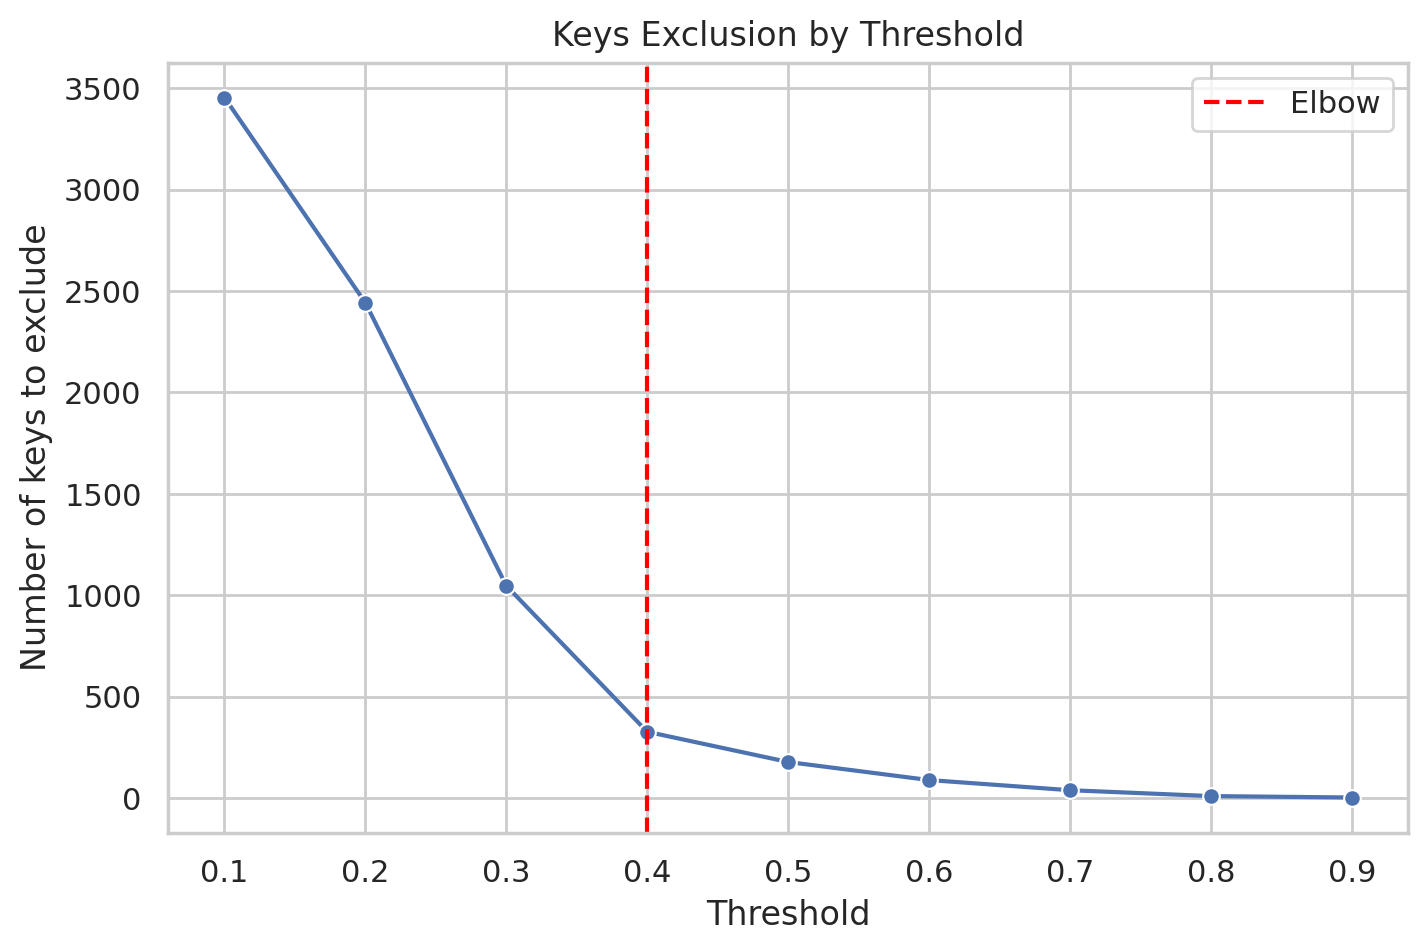

In [22]:
keys_to_exclude__by_threshold: dict[float, set[str]] = {}
thresholds: list[float] = np.arange(0.1, 0.91, 0.1).round(2).tolist()

for threshold in thresholds:
    keys_to_exclude__by_threshold[threshold] = set(
        str(x) for x in unique_keys[np.where(similarity_matrix.max(dim=1).values.cpu().numpy() > threshold)[0]]
    )

counts: list[int] = [len(keys) for keys in keys_to_exclude__by_threshold.values()]
plt.figure(figsize=(8, 5))
sns.lineplot(x=thresholds, y=counts, marker="o")
plt.xlabel("Threshold")
plt.ylabel("Number of keys to exclude")
plt.title("Keys Exclusion by Threshold")
plt.axvline(x=0.4, color="red", linestyle="--", label="Elbow")
plt.legend()
plt.show()
del counts, thresholds

There is an elbow at 0.4 that we'll use. Below listed labels names that will be excluded indeed are strongly related to attributes I want to exclude.

In [23]:
keys_to_include: set[str] = set(unique_keys) - keys_to_exclude__by_threshold[LABELS_EXCLUSION_THRESHOLD]
original__num: int = len(df)

df = df[
    df["labels"].apply(lambda x, _keys_to_include=keys_to_include: all(el in _keys_to_include for el in x))
].reset_index(drop=True)

print(
    f"Remaining samples after filtering abilities: {len(df)} "
    f"(removed {original__num - len(df)}, "  # type: ignore[misc]
    f"{((original__num - len(df)) / original__num) * 100:.2f}%)"  # type: ignore[misc]
)

del keys_to_include, original__num

Remaining samples after filtering abilities: 313042 (removed 324515, 50.90%)


In [24]:
pprint(sorted(keys_to_exclude__by_threshold[LABELS_EXCLUSION_THRESHOLD]))
del keys_to_exclude__by_threshold

['ability to explain',
 'ability to solve equations',
 'academic understanding',
 'advanced mathematics',
 'algebra',
 'algebra knowledge',
 'algebra skills',
 'algebraic reasoning',
 'algorithm',
 'algorithm application',
 'algorithm design',
 'algorithm development',
 'analogical reasoning',
 'analysis and reasoning',
 'android programming',
 'application development',
 'application of formulas',
 'arduino programming',
 'argumentation and reasoning',
 'arithmetic',
 'arithmetic calculation',
 'artificial intelligence application',
 'assembly programming',
 'associative reasoning',
 'asynchronous programming',
 'awk programming',
 'bash programming',
 'basic mathematics',
 'brainstorm',
 'c programming',
 'c# programming',
 'c++ programming',
 'calculus',
 'calculus ability',
 'calculus knowledge',
 'categorical reasoning',
 'causal reasoning',
 'clinical reasoning',
 'clojure programming',
 'code completed',
 'code conversion',
 'code design',
 'code development',
 'code editing',
 

Following cell performs deduplication based on conversation prompt messages using semhash with its default configuration.

In [25]:
df["conversation__joined"] = df["conversation"].apply(lambda x: [el["value"] for el in x]).str.join(" ")

# construct index
semhash = SemHash.from_records(records=df["conversation__joined"].tolist())

# perform deduplication and filtering of outliers
dedup_texts: set[str] = set(semhash.self_deduplicate().selected)
filtered_texts: set[str] = {e["text"] for e in semhash.self_filter_outliers().selected}
representative_texts: set[str] = dedup_texts.intersection(filtered_texts)

print(
    f"Number of unique texts after deduplication: {len(filtered_texts)} " f"(removed {len(df) - len(filtered_texts)})"
)
df = df[df["conversation__joined"].isin(representative_texts)].reset_index(drop=True)

del dedup_texts, filtered_texts, representative_texts, semhash

Number of unique texts after deduplication: 281737 (removed 31305)


After all of those operations, we're now only around 200 rows for non-english subsets.

In [26]:
df["language"].value_counts()

language
en    207838
fr       379
es       243
Name: count, dtype: int64

In [27]:
df[df["language"] == FRENCH_LANGUAGE_CODE].head(10).reset_index(drop=True)

,conversation,labels,language,n_messages,conversation__joined
0,"[{'from': 'human', 'value': 'Nommez NAME_1 les...","[multicultural understanding, data analysis, i...",fr,2,Nommez NAME_1 les meilleurs joueurs de footbal...
1,"[{'from': 'human', 'value': 'pouvez-vous nomme...","[multicultural understanding, search knowledge...",fr,2,pouvez-vous nommer la capitale du pays NAME_1 ...
2,"[{'from': 'human', 'value': 'Can you design a ...","[graphic design, creative design, problem solved]",fr,2,Can you design a unique logo from scratch? Whi...
3,"[{'from': 'human', 'value': 'Comment traduire ...","[translation, oral communication]",fr,2,"Comment traduire ""We Have No Moat"" en français..."
4,"[{'from': 'human', 'value': 'Question : Rédige...","[text generation, search knowledge, text editi...",fr,2,Question : Rédigez en français un article info...
5,"[{'from': 'human', 'value': '### Human: Your t...","[text classification, categorization and tags]",fr,2,### Human: Your task is to classify texts.\n\n...
6,"[{'from': 'human', 'value': 'Traduzca el sigui...","[project management, legal knowledge, translat...",fr,2,"Traduzca el siguiente documento al francés: ""L..."
7,"[{'from': 'human', 'value': 'Pourriez-vous réd...","[multicultural understanding, text generation,...",fr,2,Pourriez-vous rédiger en français une descript...
8,"[{'from': 'human', 'value': 'Réécris moi ça en...",[text-to-speech],fr,4,Réécris moi ça en ajoutant des trucs pour la p...
9,"[{'from': 'human', 'value': 'Bonjour, avez-vou...","[multicultural understanding, dialogue managem...",fr,2,"Bonjour, avez-vous la capacité de converser en..."


There are some problems with non-english languages labels (row 2), we'll filter them out.

In [28]:
df["detected_lang"] = None
non_en_mask: np.ndarray = df["language"] != ENGLISH_LANGUAGE_CODE
df.loc[non_en_mask, "detected_lang"] = df.loc[non_en_mask, "conversation__joined"].progress_apply(
    lambda x: language_classifier.classify_language(x[:500])
)

  0%|          | 0/622 [00:00<?, ?it/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [29]:
df["detected_lang"].value_counts()

detected_lang
fr    237
es    213
en    154
zh      7
it      5
pt      2
ur      1
ja      1
hi      1
de      1
Name: count, dtype: int64

Around 30% of non-english entries were incorrectly classified, for safety we'll remove them.

In [30]:
incorrect_mask: np.ndarray = (df["language"] != df["detected_lang"]) & df["detected_lang"].notna()
print(
    f"Number of incorrect language detections: {incorrect_mask.sum()} "
    f"({(incorrect_mask.sum() / non_en_mask.sum()) * 100:.2f}%)"
)

Number of incorrect language detections: 177 (28.46%)


In [31]:
df.drop(incorrect_mask[incorrect_mask].index, inplace=True)
df.drop(columns=["detected_lang"], inplace=True)

del incorrect_mask, non_en_mask

After all of those transformations we end up with small high quality sample of non-english rows.

In [32]:
df["language"].value_counts()

language
en    207838
fr       233
es       212
Name: count, dtype: int64

Next step is to split prompt's messages into separate sentences.

In [33]:
df["conversation"] = df["conversation"].apply(
    lambda x: [
        {"from": e["from"], "value": split_into_sentences(e["value"].strip())} for e in x if e["value"].strip() != ""
    ]
)
df["sentences__num"] = df["conversation"].apply(lambda x: sum(len(e["value"]) for e in x))
df.head(3)

,conversation,labels,language,n_messages,conversation__joined,sentences__num
0,"[{'from': 'human', 'value': ['Compose a 1500-w...","[literature search skills, writing skills, inf...",en,2,Compose a 1500-word analytical essay formatted...,121
1,"[{'from': 'human', 'value': ['Analyze the two ...","[problem solved, data analysis]",en,2,Analyze the two tables presented below concern...,11
2,"[{'from': 'human', 'value': ['Create a vividly...",[content filtering],en,2,Create a vividly detailed and provocative MCU ...,4


In [34]:
original__num: int = len(df)
df["max_sentence_length"] = df["conversation"].apply(
    lambda x: max(len(sentence) for turn in x for sentence in turn["value"]) if x else 0
)
df = df[df["max_sentence_length"] <= MAX_SENTENCE_LENGTH].reset_index(drop=True)
df.drop(columns=["max_sentence_length"], inplace=True)

print(
    f"Remaining samples after filtering abilities: {len(df)} "
    f"(removed {original__num - len(df)}, "  # type: ignore[misc]
    f"{((original__num - len(df)) / original__num) * 100:.2f}%)"  # type: ignore[misc]
)
del original__num

Remaining samples after filtering abilities: 62731 (removed 145552, 69.88%)


Let's check for number of turns distribution - one-turn conversations clearly dominate. For clear display we exclude irrelevant entries with less than 50 records.

In [35]:
df["n_messages"].astype(int).value_counts()[lambda x: x >= 50].reset_index()  # pylint: disable=magic-value-comparison

,n_messages,count
0,2,61140
1,6,612
2,4,560
3,8,419


# Multilingual dataset

For that subset we pick 33 messages from each of 3 languages: English, Spanish and French. We limit them to first message from human, creating that way 1 turn conversation. Dataset is saved in same format as 1 turn datasets constructed from VoiceBench, that is with "prompt" column instead of "conversation" column.

### Dataset preparation

In [74]:
multilingual__df: pd.DataFrame = (
    df.groupby("language", as_index=False)
    .apply(lambda g: g.sample(n=100, random_state=0))
    .reset_index(drop=True)
    .rename(columns={"conversation": "prompt"})
)

multilingual__df["sentences"] = multilingual__df["prompt"].apply(lambda x: x[0]["value"])
multilingual__df["original_language"] = multilingual__df["language"]

# recalculate after dropping last message
multilingual__df["n_messages"] -= 1
multilingual__df["sentences__num"] = multilingual__df["sentences"].apply(len)
multilingual__df["conversation__joined"] = multilingual__df["sentences"].str.join(" ")

print(f"Number of unique text entries and size of the multilingual dataset: {len(multilingual__df)}")

Number of unique text entries and size of the multilingual dataset: 300


In [75]:
# Compute token counts for multi-sentence dataset
multilingual__df["token_count"] = compute_multi_turn_token_counts(multilingual__df, sentences_column="sentences")
print(f"Computed token counts for {len(multilingual__df)} entries.")

multi-turn token counting:   0%|          | 0/300 [00:00<?, ?it/s]

Computed token counts for 300 entries.


Text(0.5, 0, 'token_count')

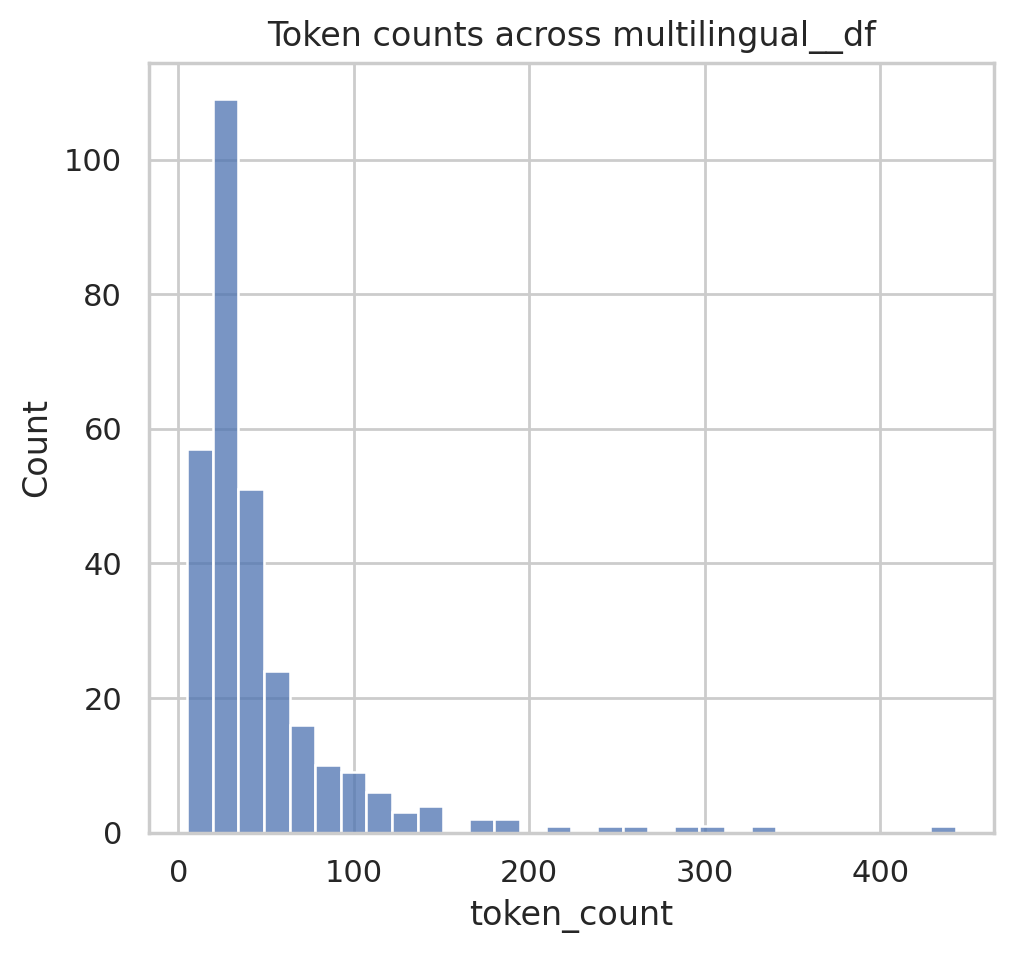

In [76]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(multilingual__df["token_count"], bins=30, kde=False)
plt.title("Token counts across multilingual__df")
plt.xlabel("token_count")

In [77]:
MAX_TOKEN_COUNT_ML = 40  # maximum token count to consider for multi-lingual
# Choose ALL entries with token_count <= 40
multilingual__df = multilingual__df[multilingual__df["token_count"] <= MAX_TOKEN_COUNT_ML].copy()
print(f"Candidates with token_count <= 40: {len(multilingual__df)}")

Candidates with token_count <= 40: 191


In [78]:
multilingual__df = (
    multilingual__df.groupby("language", as_index=False)
    .apply(lambda g: g.sample(n=33, random_state=0))
    .reset_index(drop=True)
)

Text(0.5, 0, 'token_count')

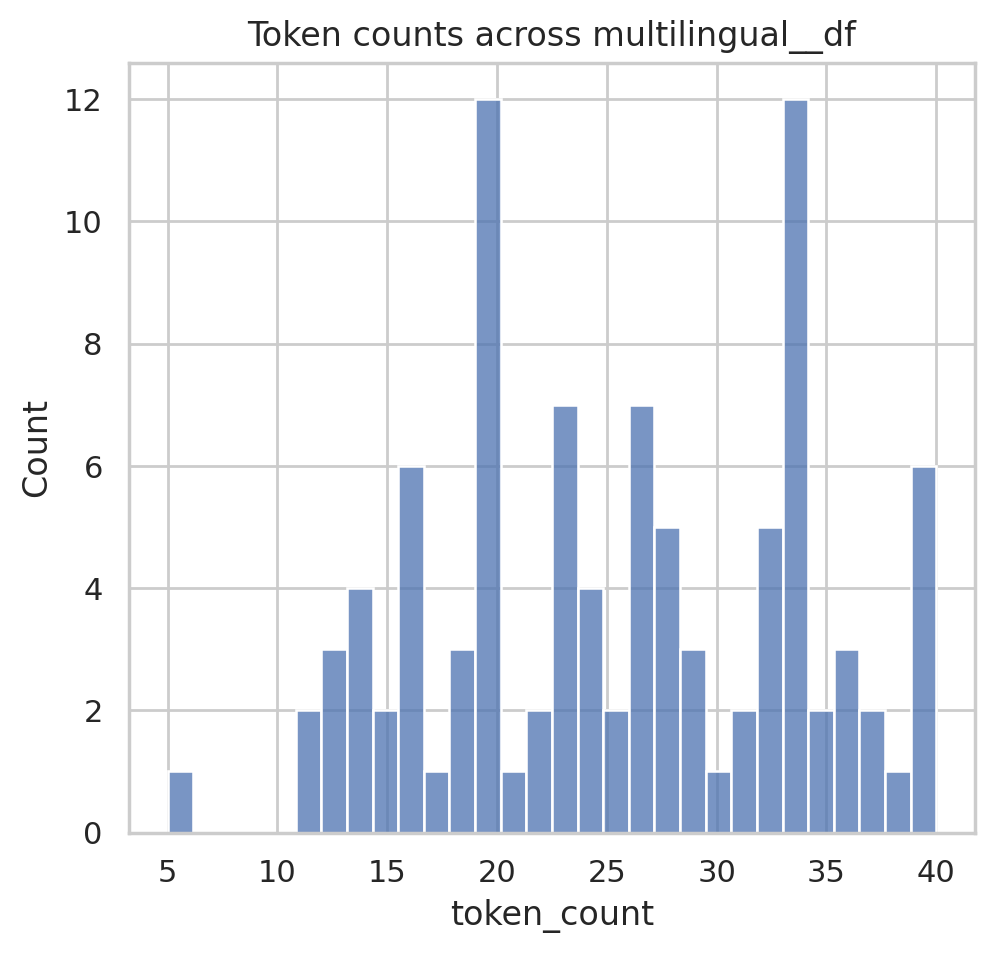

In [79]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(multilingual__df["token_count"], bins=30, kde=False)
plt.title("Token counts across multilingual__df")
plt.xlabel("token_count")

Lets check for most popular labels:

In [80]:
counts: np.ndarray = multilingual__df["labels"].explode().value_counts()
pprint(counts)  # type: ignore[misc] # pylint: disable=magic-value-comparison
del counts

labels
translation                       26
multicultural understanding       23
information search                15
natural language understanding    11
text generation                   10
                                  ..
dialogue management                1
customer service                   1
topic discussion                   1
general dialogue understanding     1
polite interaction                 1
Name: count, Length: 111, dtype: int64


In [83]:
multilingual__df__translated = pd.DataFrame()

for language in INFINITY_INSTRUCT__CONFIG.languages:
    print(f"Translating from {language}...")
    multilingual__df__to_translate = multilingual__df[multilingual__df["language"] == language].copy()

    for _target_language in INFINITY_INSTRUCT__CONFIG.languages:
        if _target_language != language:
            _multilingual__df__to_translate = multilingual__df__to_translate.copy()
            _multilingual__df__to_translate["language"] = _target_language
            _multilingual__df__to_translate = await language_translator.translate_df(  # type: ignore[top-level-await] # pylint: disable=await-outside-async # noqa: E501,F704
                _multilingual__df__to_translate, _target_language
            )
            _multilingual__df__to_translate["prompt"] = _multilingual__df__to_translate["conversation__joined"].apply(
                split_into_sentences
            )
            _multilingual__df__to_translate["sentences__num"] = _multilingual__df__to_translate["prompt"].apply(len)
            multilingual__df__translated = pd.concat([multilingual__df__translated, _multilingual__df__to_translate])

multilingual__df = pd.concat([multilingual__df, multilingual__df__translated]).reset_index(drop=True)

del multilingual__df__to_translate, multilingual__df__translated, _multilingual__df__to_translate

Translating from en...


100%|██████████| 33/33 [00:01<00:00, 20.96it/s]


Translating from es...


100%|██████████| 33/33 [00:02<00:00, 14.03it/s]


Translating from fr...


100%|██████████| 33/33 [00:01<00:00, 26.15it/s]


In [89]:
multilingual__df[multilingual__df["language"] != multilingual__df["original_language"]].head(3)

,prompt,labels,language,n_messages,conversation__joined,sentences__num,sentences,original_language,token_count,audio__male,audio__female,audio__male__duration,audio__female__duration
99,[La madre expulsa gases audiblemente durante u...,"[narrative comprehension, scene reconstruction...",es,1,La madre expulsa gases audiblemente durante un...,1,[Mother audibly passes gas during a profession...,en,20,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[7.392],[7.2]
100,[¿Podrías ofrecer una crítica editorial en pro...,"[text generation, knowledge query, information...",es,1,¿Podrías ofrecer una crítica editorial en prof...,1,[Could you provide an in-depth editorial criti...,en,28,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[11.52],[10.584]
101,[Imagina que estás en un escenario en el que d...,"[scenarios simulation, persuasiveness]",es,1,Imagina que estás en un escenario en el que de...,1,[Imagine you are in a scenario where you must ...,en,39,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[12.768],[12.12]


In [90]:
multilingual__df["language"].value_counts()

language
en    99
es    99
fr    99
Name: count, dtype: int64

Lets synthesize audio representation.

In [86]:
multilingual__df["audio__male"] = None
multilingual__df["audio__female"] = None

for language, configs in TTS_CONFIGS.items():
    keys_to_update: pd.Series = multilingual__df["language"] == language
    if not keys_to_update.any():
        continue
    multilingual__df__part: pd.DataFrame = multilingual__df.loc[keys_to_update, ["sentences"]].copy()
    male_config: TTSConfig = configs["male"]
    female_config: TTSConfig = configs["female"]

    for name, config in (
        ("male", male_config),
        ("female", female_config),
    ):
        multilingual__df__part = await tts.synthesize_df_from_config(  # type: ignore[top-level-await] # pylint: disable=await-outside-async # noqa: E501,F704
            multilingual__df__part,
            config,
            column_to_synthesize="sentences",
            target_column=f"audio__{name}",
        )

        multilingual__df.loc[keys_to_update, f"audio__{name}"] = multilingual__df__part[f"audio__{name}"]
        multilingual__df__part.drop(columns=[f"audio__{name}"], inplace=True)

    del keys_to_update, multilingual__df__part, configs, male_config, female_config

multilingual__df["audio__male__duration"] = multilingual__df["audio__male"].progress_apply(calculate_audio_duration)
multilingual__df["audio__female__duration"] = multilingual__df["audio__female"].progress_apply(calculate_audio_duration)

Synthesizing: 100%|██████████| 99/99 [00:02<00:00, 40.82it/s]


  0%|          | 0/297 [00:00<?, ?it/s]

  0%|          | 0/297 [00:00<?, ?it/s]

### Stats

In [92]:
pprint(get_df_stats(multilingual__df))

{'audio__female__duration__average': 8.07,
 'audio__female__duration__total': 2396.98,
 'audio__male__duration__average': 7.85,
 'audio__male__duration__total': 2330.06,
 'avg_characters__num': 121.49,
 'avg_sentences__num': 1.3,
 'characters__num': 36082,
 'min_sentences__num': 1,
 'rows__num': 297,
 'total_sentences__num': 386,
 'unique_entries__num': 295,
 'unique_entries__pct': 99.33}


## Save dataset and samples

In [95]:
multilingual__df__to_save = multilingual__df.drop(columns=["conversation__joined", "prompt"])
save_parquet(multilingual__df__to_save, INFINITY_INSTRUCT__CONFIG.data_dir / "multi_lingual.parquet")

In [96]:
multilingual__df__to_save.head(3)

,labels,language,n_messages,sentences__num,sentences,original_language,token_count,audio__male,audio__female,audio__male__duration,audio__female__duration
0,"[narrative comprehension, scene reconstruction...",en,1,1,[Mother audibly passes gas during a profession...,en,20,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[6.648],[6.816]
1,"[text generation, knowledge query, information...",en,1,1,[Could you provide an in-depth editorial criti...,en,28,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[9.24],[9.432]
2,"[scenarios simulation, persuasiveness]",en,1,1,[Imagine you are in a scenario where you must ...,en,39,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[10.608],[10.584]



### Processed samples

In [99]:
sample__df: pd.DataFrame = get_sample_df(multilingual__df__to_save)
save_json(sample__df, INFINITY_INSTRUCT__CONFIG.data_dir / "multi_lingual__text__sample.json")
sample__df.head(3)

,label,sentences,sentences__num,language
0,ability to describe,[Describe a thunderstorm from the perspective ...,2,en
1,ability to describe,[Describe a thunderstorm from the perspective ...,2,es
2,ability to describe,[Describe a thunderstorm from the perspective ...,2,fr


### Section cleanup

In [100]:
del sample__df, multilingual__df, multilingual__df__to_save

# Cleanup

In [101]:
shutil.rmtree(INFINITY_INSTRUCT__CONFIG.cache_dir)